# RDR2 Dataset — Capture Statistics
This notebook loads `all-captures.json` and visualises key statistics about the captures and annotated entities.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

## 1  Load data

In [3]:
DATA_PATH = Path('all_captures.json')

with open(DATA_PATH) as f:
    raw = json.load(f)

print(f'Total captures: {len(raw)}')

Total captures: 27686


## 2  Build flat DataFrames

In [4]:
captures, entities = [], []

for cid, record in raw.items():
    cap = record['Capture']
    captures.append({
        'capture_id':        int(cid),
        'daytime_category':  cap.get('DaytimeCategory'),
        'daytime':           cap.get('Daytime'),
        'weather':           cap.get('Weather'),
        'temperature':       cap.get('Temperature'),
        'exposure':          cap.get('Exposure'),
        'fov':               cap.get('CameraFOV'),
        'cam_above_ground':  cap.get('CameraAboveGround'),
        'cam_dist_player':   cap.get('CameraDistanceToPlayer'),
        'entity_count':      cap.get('EntityCount'),
        'zone':              cap.get('Zone'),
    })
    for ent in record.get('Entities', []):
        bbox = ent.get('BoundingBoxCalculated', [None]*4)
        w = (bbox[2] - bbox[0]) if bbox[0] is not None else None
        h = (bbox[3] - bbox[1]) if bbox[1] is not None else None
        entities.append({
            'capture_id':          int(cid),
            'entity_id':           ent.get('ID'),
            'fine_class':          ent.get('FineClassName'),
            'coarse_class':        ent.get('CoarseClassName'),
            'distance':            ent.get('Distance'),
            'height_above_ground': ent.get('HeightAboveGround'),
            'in_water':            ent.get('InWater'),
            'pct_mask_image':      ent.get('PercentageMaskImage', 0) * 100,  # → %
            'pct_mask_bbox':       ent.get('PercentageMaskBbox', 0),
            'bbox_w':              w,
            'bbox_h':              h,
            'bbox_area':           (w * h) if (w and h) else None,
            'weather':             cap.get('Weather'),
            'daytime_category':    cap.get('DaytimeCategory'),
        })

df_cap = pd.DataFrame(captures)
df_ent = pd.DataFrame(entities)

print(df_cap.shape, df_ent.shape)
df_cap.head(3)

(27686, 11) (66917, 14)


,capture_id,daytime_category,daytime,weather,temperature,exposure,fov,cam_above_ground,cam_dist_player,entity_count,zone
0,1000002,noon,12:29:3,SNOWLIGHT,3.593028,0.0,70.0,7.289886,96.075745,7,Unknown_0
1,1000003,morning,10:37:15,HIGHPRESSURE,22.976963,0.0,70.0,2.738338,175.517578,5,Unknown_0
2,1000004,noon,12:37:49,MISTY,29.338482,0.0,70.0,1.644400,119.406853,5,Unknown_0


## 3  Capture-level overview

In [5]:
df_cap.describe()

,capture_id,temperature,exposure,fov,cam_above_ground,cam_dist_player,entity_count
count,2.768600e+04,27686.000000,27686.0,27686.0,27686.000000,27686.000000,27686.000000
mean,1.018267e+06,13.089845,0.0,70.0,19.544191,115.099907,2.416998
std,1.025297e+04,10.476488,0.0,0.0,25.332322,64.128151,2.289305
min,1.000002e+06,-19.022573,0.0,70.0,-7.261754,1.787935,0.000000
25%,1.009409e+06,6.741093,0.0,70.0,3.571642,81.519327,1.000000
50%,1.018598e+06,13.646021,0.0,70.0,12.248814,109.768188,2.000000
75%,1.027108e+06,22.106212,0.0,70.0,30.236397,145.167217,3.000000
max,1.035896e+06,35.566002,0.0,70.0,458.237213,4902.965820,37.000000


## 4  Weather & daytime distribution

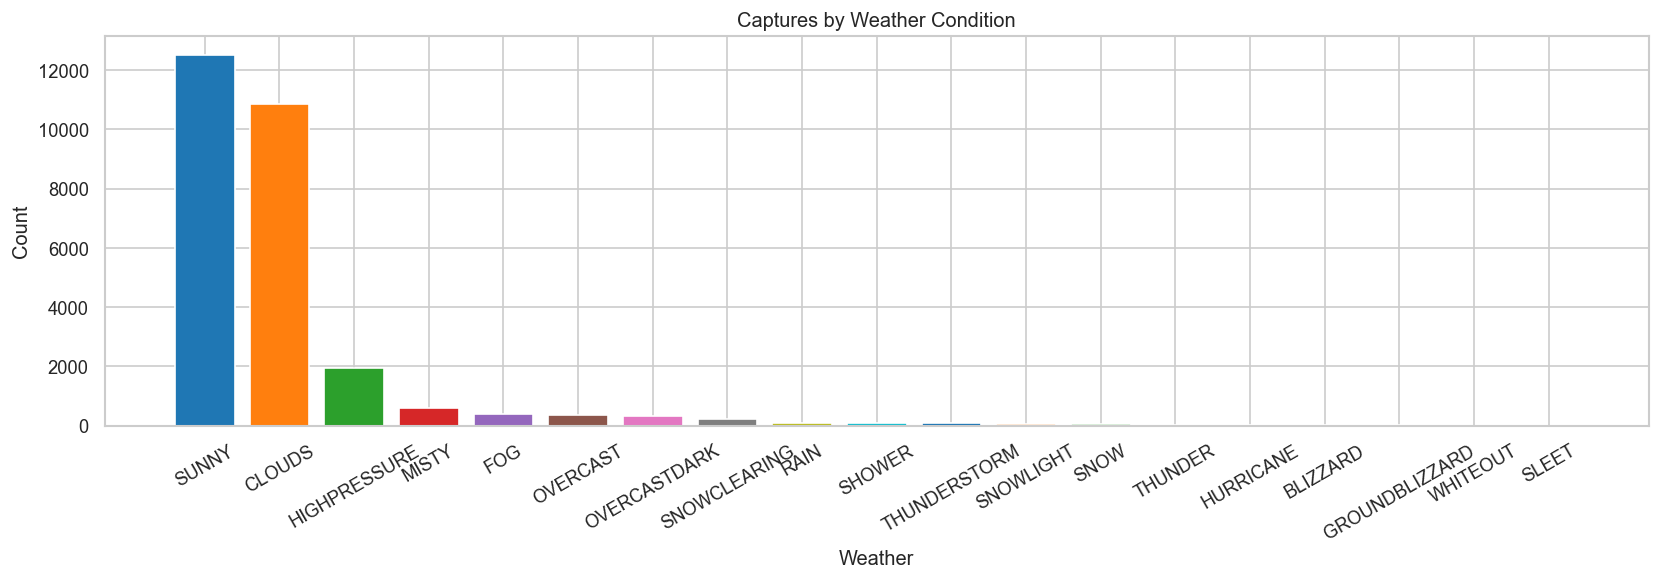

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

# Weather
weather_counts = df_cap['weather'].value_counts()
ax.bar(weather_counts.index, weather_counts.values, color=sns.color_palette('tab10', len(weather_counts)))
ax.set_title('Captures by Weather Condition')
ax.set_xlabel('Weather')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)



plt.tight_layout()
plt.show()

In [34]:
# Get a mapping between coarse and fine classes
coarse_to_fine = df_ent.groupby('coarse_class')['fine_class'].apply(lambda x: set(x.dropna().unique())).to_dict()
#print("Coarse to Fine Class Mapping:")
#for coarse, fines in coarse_to_fine.items():
 #   print(f"  {coarse}: {', '.join(fines)}")

# map fine to coarse for easier lookup
fine_to_coarse = {fine: coarse for coarse, fines in coarse_to_fine.items() for fine in fines}


# Get class count of fine classes within each coarse class as a dict of dicts
coarse_fine_counts = {}
for coarse, fines in coarse_to_fine.items():
    counts = df_ent[df_ent['coarse_class'] == coarse]['fine_class'].value_counts()
    print(counts)
    coarse_fine_counts[coarse] = counts
    
print("Fine Class Counts within Each Coarse Class:")
for coarse, counts in coarse_fine_counts.items():
    print(f"  {coarse}:")
    for fine, count in counts.items():
        print(f"    {fine}: {count}")

# Plot fine class distributions grouped by coarse class
print(coarse_fine_counts)





fine_class
alligator    250
Name: count, dtype: int64
fine_class
armadillo    38
Name: count, dtype: int64
fine_class
badger    48
Name: count, dtype: int64
fine_class
bat    181
Name: count, dtype: int64
fine_class
bearblack    419
bear          62
Name: count, dtype: int64
fine_class
beaver    53
Name: count, dtype: int64
fine_class
raven               6543
crow                5191
cedarwaxwing        3731
oriole              3308
sparrow             3256
seagull             2274
goosecanada         2265
cardinal            2194
turkey              2143
duck                2032
pelican             2002
songbird            1900
cormorant           1806
prairiechicken      1486
heron               1470
bluejay             1130
pheasant            1059
hawk                 795
loon                 633
vulture              587
quail                585
owl                  214
woodpecker           198
californiacondor     194
eagle                191
roseatespoonbill     148
cranewhooping

## 5  Entity class distribution

TypeError: 'numpy.ndarray' object is not callable

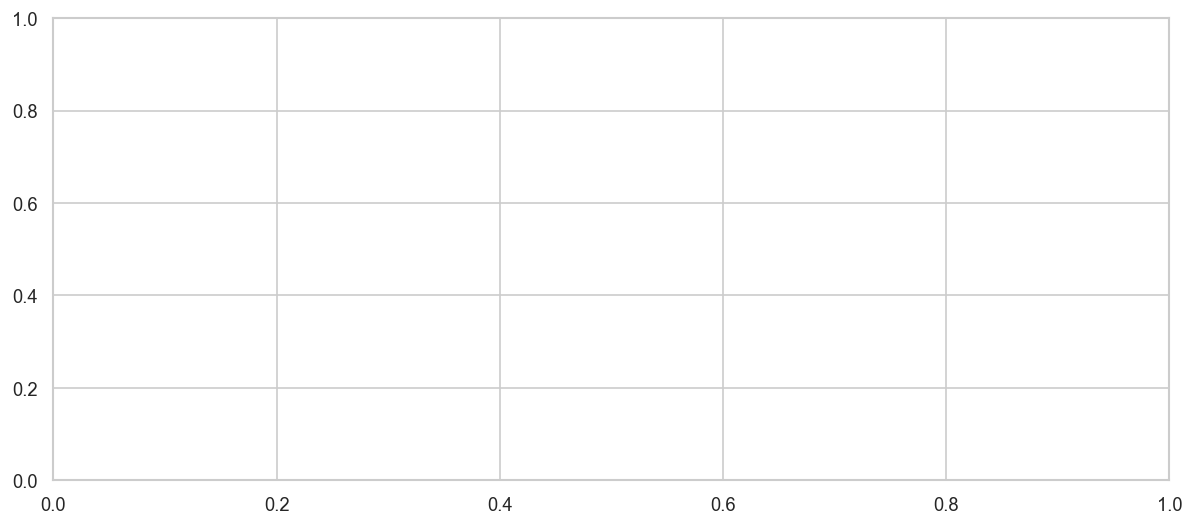

In [ ]:

# 1. Define the hierarchical data structure
data = {
    "flat": {"road": 4e9, "sidewalk": 5e8, "parking": 6e7, "rail track": 1.5e7},
    "construction": {"build.": 2e9, "fence": 7e7, "wall": 6e7, "bridge": 2.3e7},
    "nature": {"veget.": 1.5e9, "terrain": 1.1e8},
    "vehicle": {"car": 7e8, "bicycle": 4e7, "bus": 3.2e7, "truck": 2.5e7},
    "sky": {"sky": 4e8},
}

# Distinct color palette for categories
category_colors = ["#a06ab4", "#777777", "#90bc5c", "#4c54ad", "#85b3db"]

fig, ax = plt.subplots(figsize=(12, 5))

current_x = 0  # Track x-position
category_ticks = []
category_labels = []

# 2. Plot bars group by group
for i, (cat_name, sub_dict) in enumerate(coarse_fine_counts.items()):
    sub_classes = list(sub_dict.keys())
    values = list(sub_dict.values())
    
    # Define x-positions for the current sub-group
    x_positions = np.arange(current_x, current_x + len(sub_classes))
    
    # Plot the bars for this category group
    ax.bar(x_positions, values, color=category_colors[i], width=0.85, edgecolor='black', linewidth=0.5)
    
    # Label each individual sub-class bar on top
    for x, sub_class in zip(x_positions, sub_classes):
        ax.text(x, values[0] * 1.5, sub_class, rotation=90, ha='center', va='bottom', fontsize=9)
        
    # Calculate middle position of the group for the bottom category label
    group_center = (x_positions[0] + x_positions[-1]) / 2
    category_ticks.append(group_center)
    category_labels.append(cat_name)
    
    # Move x-pointer forward, adding extra spacing between groups
    current_x += len(sub_classes) + 1

# 3. Apply styling, log scale, and grid lines
ax.set_yscale('log')
ax.set_ylim(1e6, 3e10)
ax.set_ylabel("number of pixels", fontsize=11)
ax.grid(axis='y', which='both', linestyle='-', linewidth=0.5, alpha=0.7)

# Set the grouped category labels on the main x-axis
ax.set_xticks(category_ticks)
ax.set_xticklabels(category_labels, fontsize=11, fontweight='bold')

# Remove top/right spines and clear default sub-ticks text
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', which='both', bottom=False) 

plt.tight_layout()
plt.show()

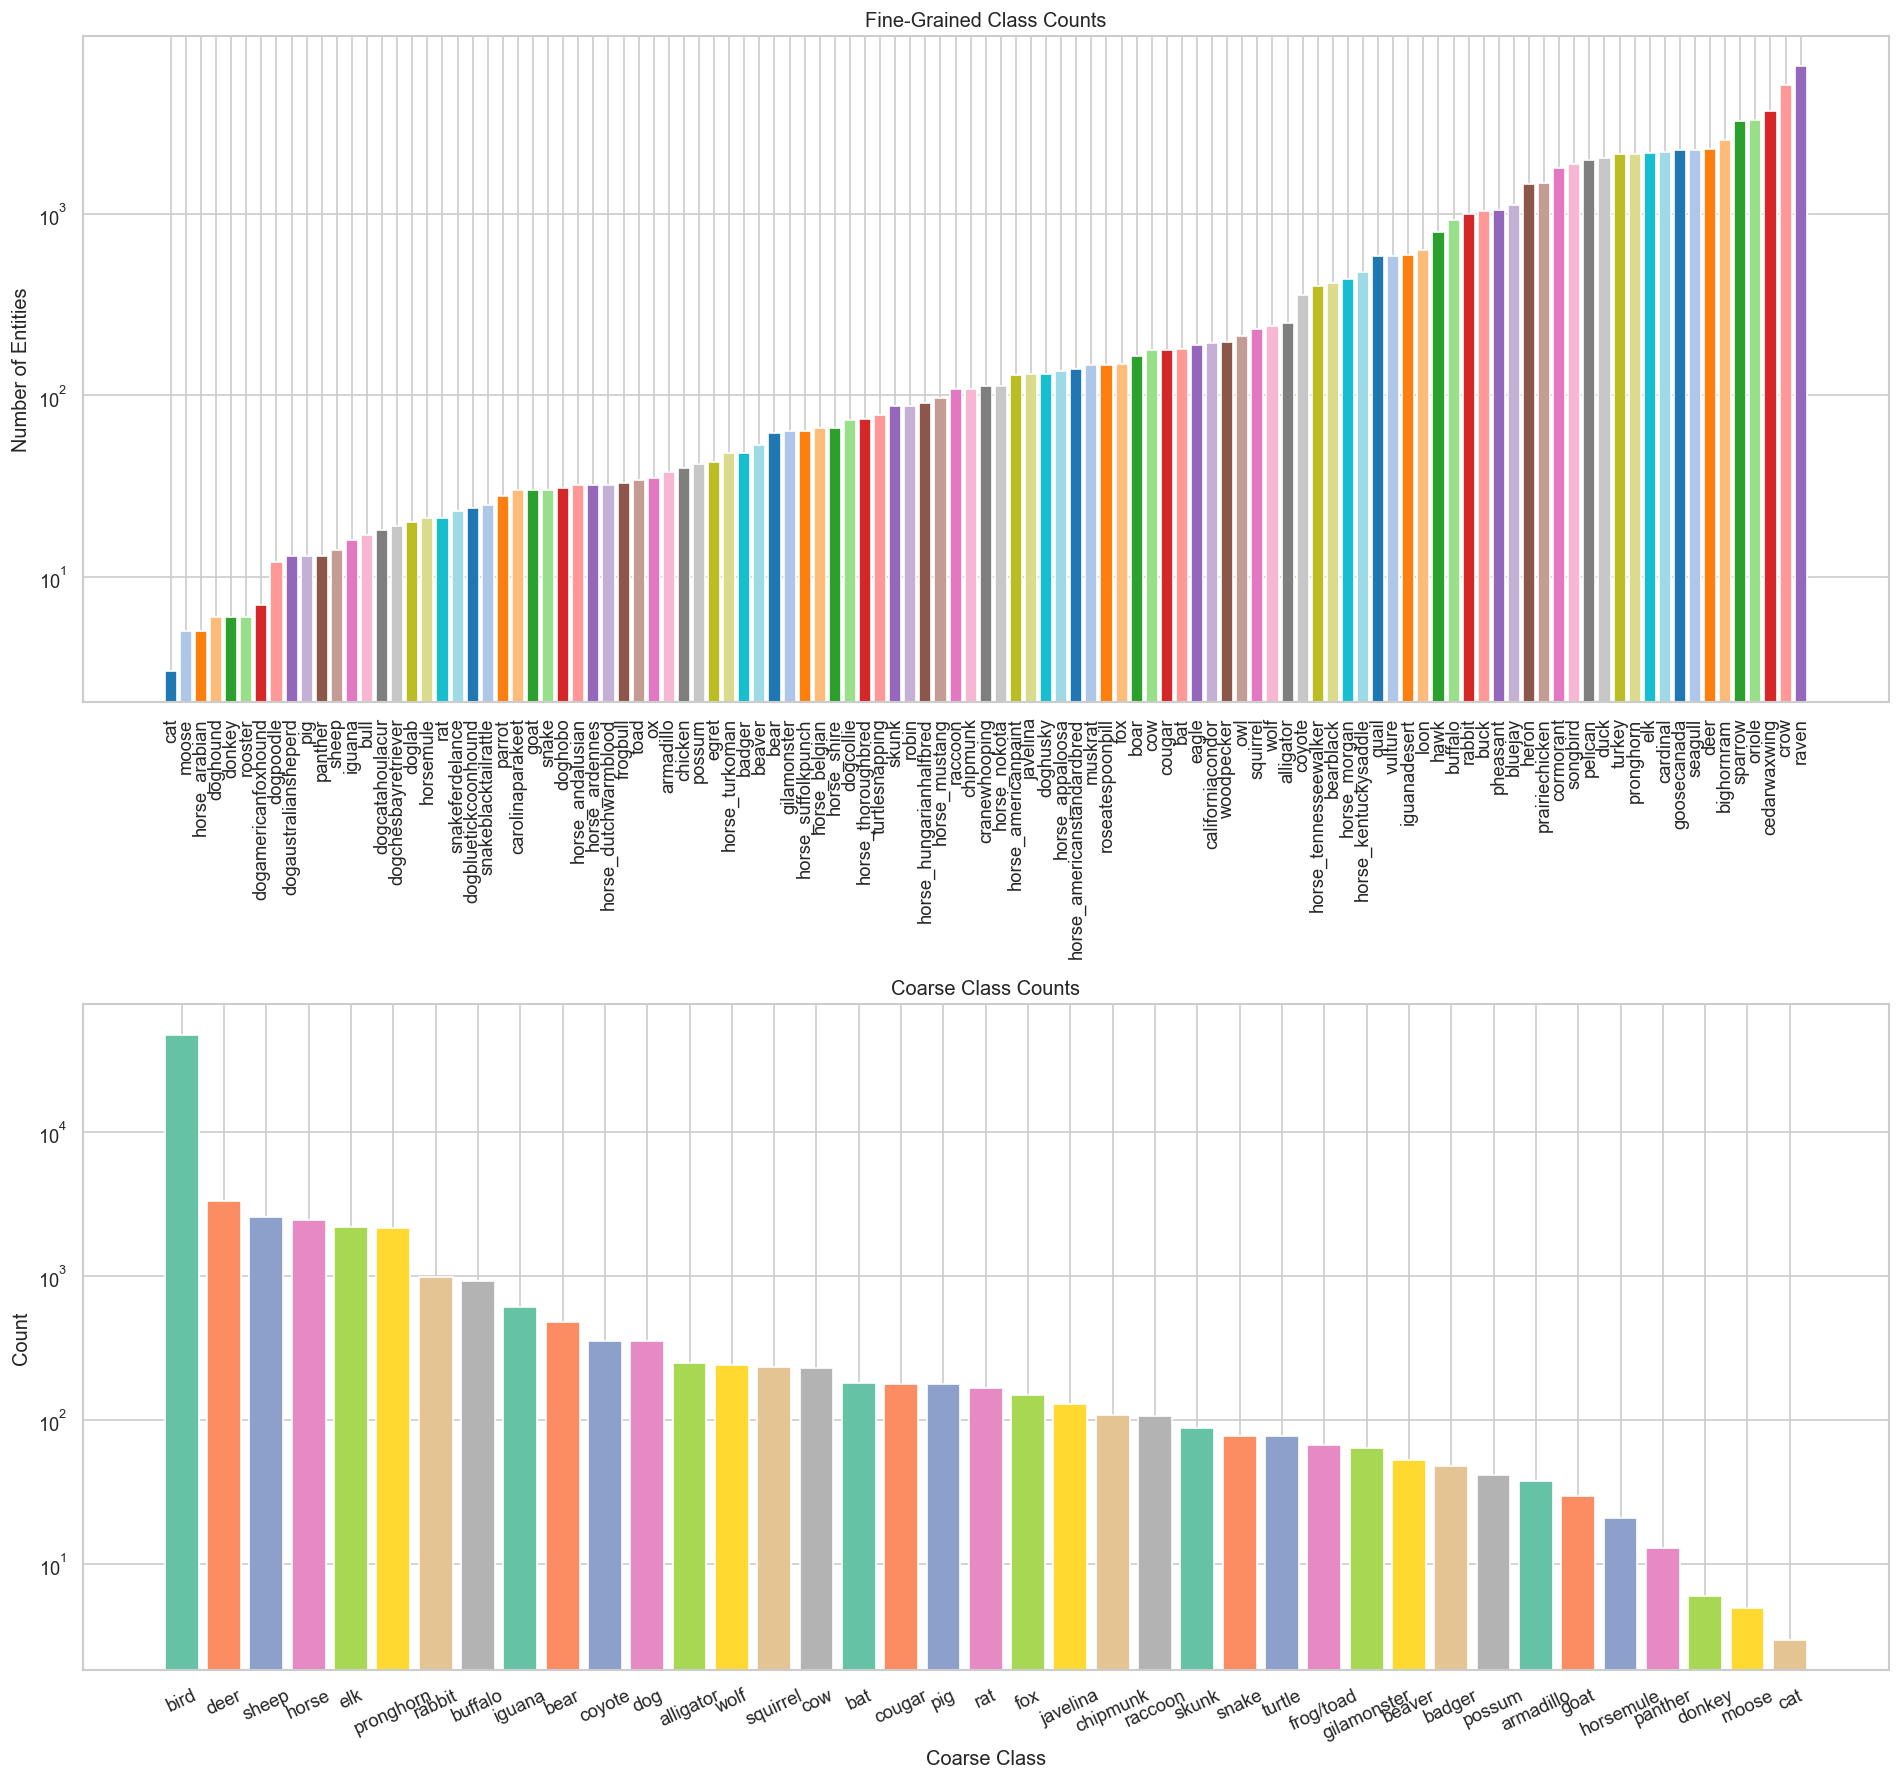

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 15))

# Fine class
fine_counts = df_ent['fine_class'].value_counts()
axes[0].bar(fine_counts.index[::-1], fine_counts.values[::-1],
             color=sns.color_palette('tab20', len(fine_counts)))
axes[0].set_title('Fine-Grained Class Counts')
# log x-axis for better visibility of smaller classes
axes[0].set_yscale('log')
axes[0].set_ylabel('Number of Entities')
axes[0].tick_params(axis='x', rotation=90)

# Coarse class
coarse_counts = df_ent['coarse_class'].value_counts()
axes[1].bar(coarse_counts.index, coarse_counts.values,
            color=sns.color_palette('Set2', len(coarse_counts)))
axes[1].set_title('Coarse Class Counts')
axes[1].set_xlabel('Coarse Class')
axes[1].set_ylabel('Count')
# log y-axis for better visibility of smaller classes
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 6  Entities per capture

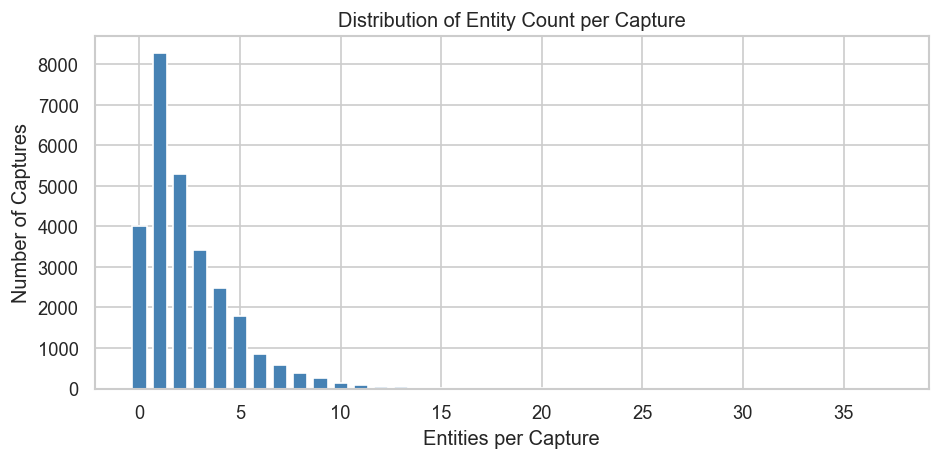

count    27686.000000
mean         2.416998
std          2.289305
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         37.000000
Name: entity_count, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ec = df_cap['entity_count']
bins = range(ec.min(), ec.max() + 2)
ax.hist(ec, bins=bins, align='left', rwidth=0.7, color='steelblue', edgecolor='white')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Distribution of Entity Count per Capture')
ax.set_xlabel('Entities per Capture')
ax.set_ylabel('Number of Captures')
plt.tight_layout()
plt.show()

print(ec.describe())

## 7  Distance to camera

C:\Users\dekav\AppData\Local\Temp\ipykernel_11016\372145194.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


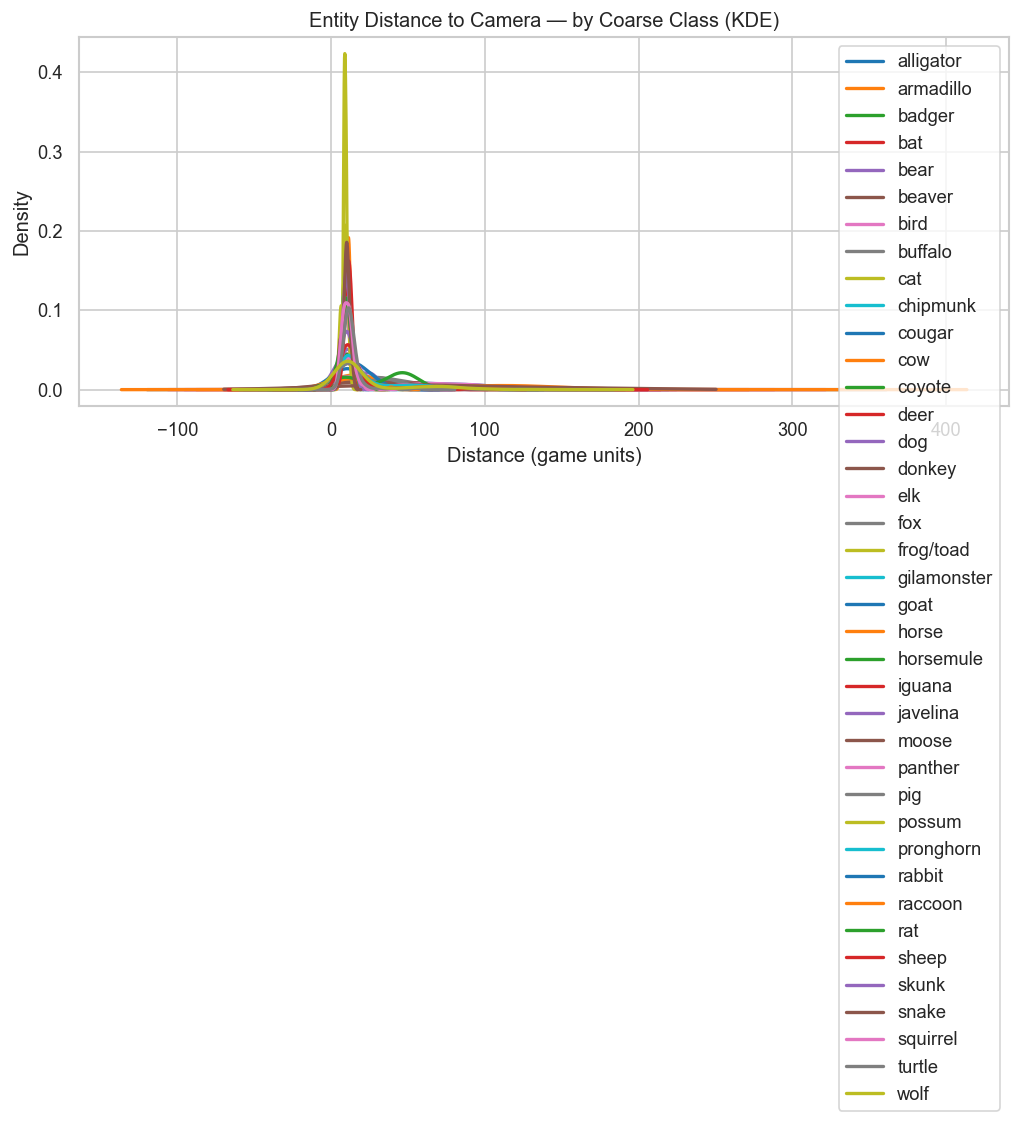

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls, grp in df_ent.groupby('coarse_class'):
    grp['distance'].dropna().plot.kde(ax=ax, label=cls, linewidth=2)
ax.set_title('Entity Distance to Camera — by Coarse Class (KDE)')
ax.set_xlabel('Distance (game units)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 8  Bounding-box size vs. distance

C:\Users\dekav\AppData\Local\Temp\ipykernel_11016\3905333379.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


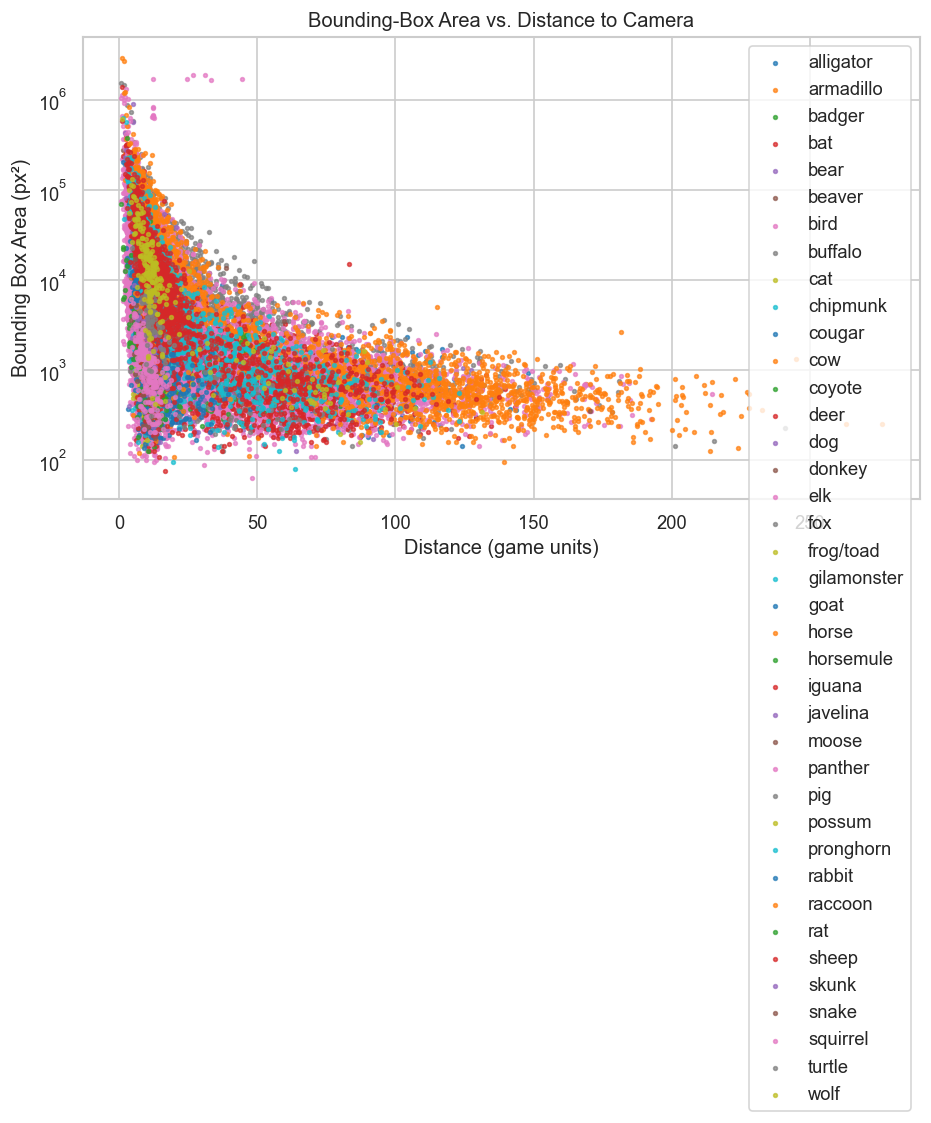

In [23]:
df_plot = df_ent.dropna(subset=['distance', 'bbox_area', 'coarse_class'])
fig, ax = plt.subplots(figsize=(9, 5))
for cls, grp in df_plot.groupby('coarse_class'):
    ax.scatter(grp['distance'], grp['bbox_area'], label=cls, alpha=0.7, s=5)
ax.set_title('Bounding-Box Area vs. Distance to Camera')
ax.set_xlabel('Distance (game units)')
ax.set_ylabel('Bounding Box Area (px²)')
# log scale for better visibility of smaller boxes
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 9  Mask coverage (% of image)

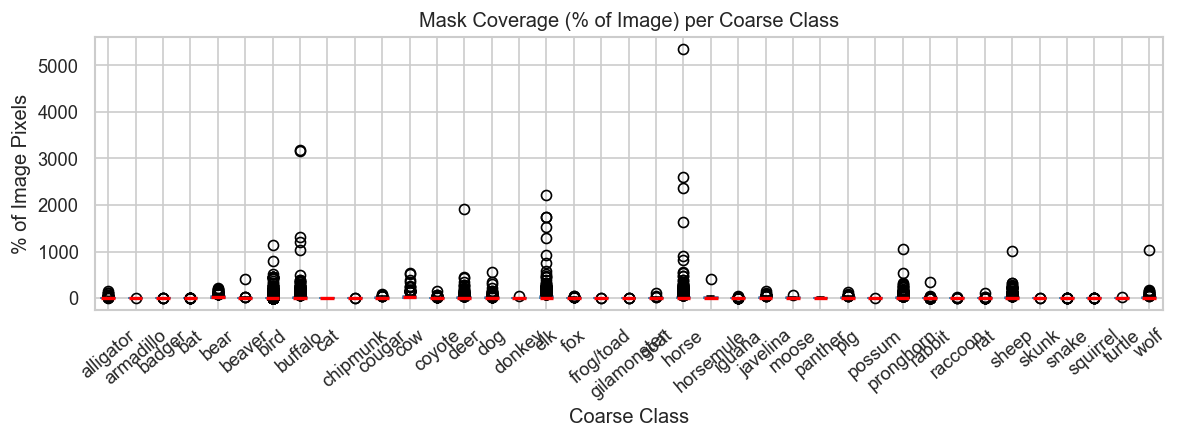

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
order = df_ent.groupby('coarse_class')['pct_mask_image'].median().sort_values(ascending=False).index
df_ent.boxplot(column='pct_mask_image', by='coarse_class', ax=ax,
               boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
ax.set_title('Mask Coverage (% of Image) per Coarse Class')
ax.set_xlabel('Coarse Class')
ax.set_ylabel('% of Image Pixels')
plt.suptitle('')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

## 10  Temperature distribution across weather conditions

C:\Users\dekav\AppData\Local\Temp\ipykernel_11016\3187909269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cap, x='weather', y='temperature', order=order, ax=ax, palette='coolwarm')


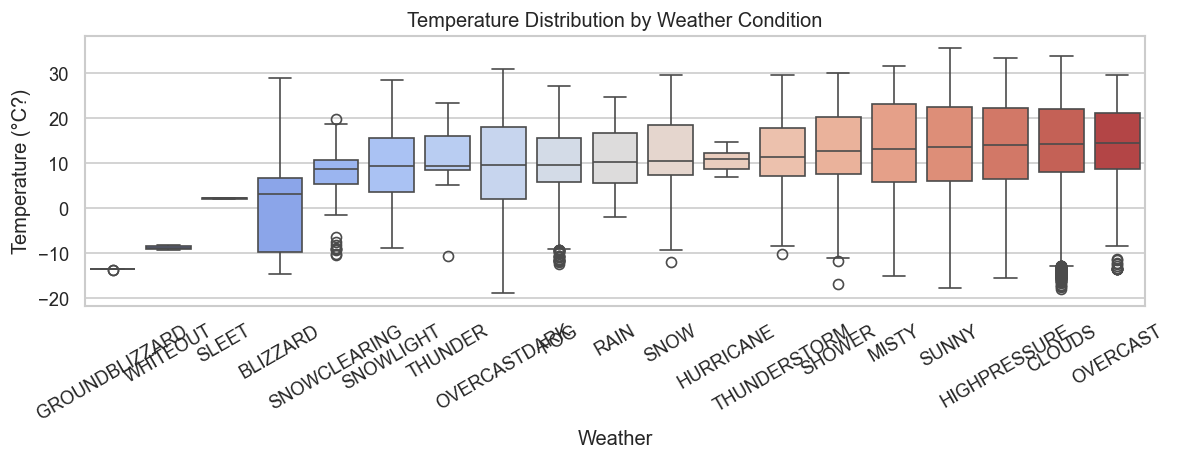

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
order = df_cap.groupby('weather')['temperature'].median().sort_values().index
sns.boxplot(data=df_cap, x='weather', y='temperature', order=order, ax=ax, palette='coolwarm')
ax.set_title('Temperature Distribution by Weather Condition')
ax.set_xlabel('Weather')
ax.set_ylabel('Temperature (°C?)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 11  Height above ground per coarse class

C:\Users\dekav\AppData\Local\Temp\ipykernel_11016\936443767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ent, x='coarse_class', y='height_above_ground', ax=ax,


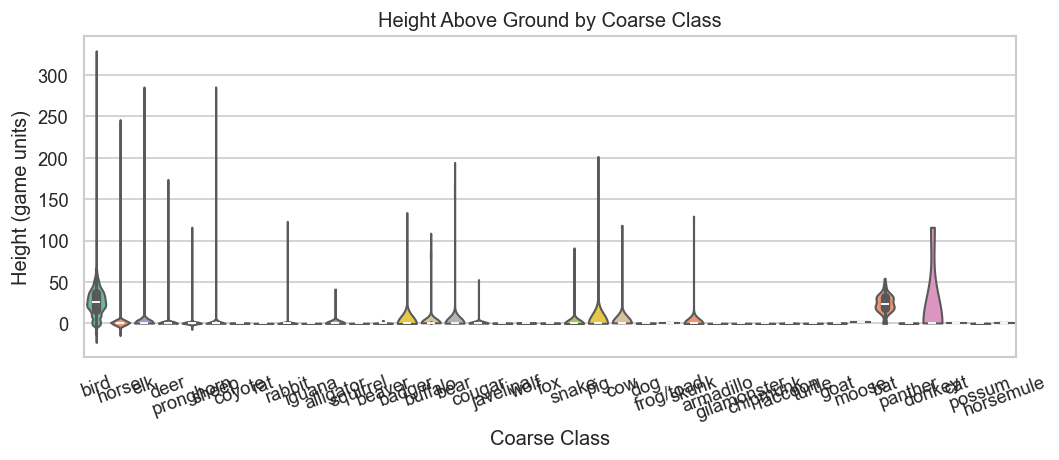

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(data=df_ent, x='coarse_class', y='height_above_ground', ax=ax,
               palette='Set2', cut=0, inner='box')
ax.set_title('Height Above Ground by Coarse Class')
ax.set_xlabel('Coarse Class')
ax.set_ylabel('Height (game units)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 12  Correlation heatmap (numeric capture fields)

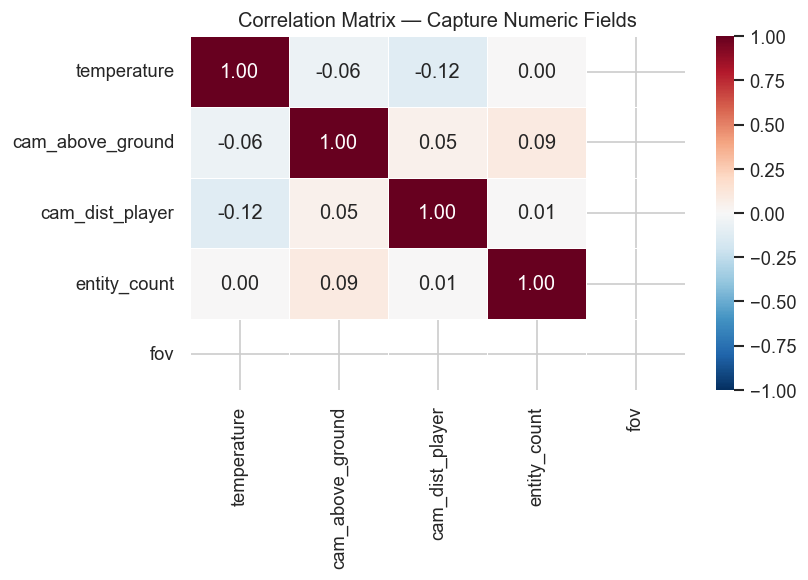

In [16]:
num_cols = ['temperature', 'cam_above_ground', 'cam_dist_player', 'entity_count', 'fov']
corr = df_cap[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax,
            linewidths=0.5)
ax.set_title('Correlation Matrix — Capture Numeric Fields')
plt.tight_layout()
plt.show()

## 13  Summary table

In [17]:
summary = (
    df_ent.groupby('fine_class')
    .agg(
        count=('entity_id', 'count'),
        mean_distance=('distance', 'mean'),
        mean_bbox_area=('bbox_area', 'mean'),
        mean_pct_mask=('pct_mask_image', 'mean'),
    )
    .round(2)
    .sort_values('count', ascending=False)
)
print(summary.to_string())

                            count  mean_distance  mean_bbox_area  mean_pct_mask
fine_class                                                                     
raven                        6543          17.98        10082.19           8.78
crow                         5191          11.67         4703.13           4.14
cedarwaxwing                 3731           8.06         1066.42           0.86
oriole                       3308           7.94         1046.58           0.79
sparrow                      3256           7.91          961.46           0.73
bighornram                   2568          20.25        17238.52          18.52
deer                         2284          34.08        14223.89          13.35
seagull                      2274          15.84         5391.55           3.75
goosecanada                  2265          16.93         7140.89           5.54
cardinal                     2194           9.52         1100.23           0.86
elk                          2188       